# Penguin Species Classification with a PyTorch MLP

> **Author:** Augusto Stahlschmidt<br />
> **Date:** 2025  

---

## 1. Introduction & Objectives

**Problem:**  
The Palmer Penguins dataset contains biometric measurements of three penguin species collected at the Palmer Archipelago, Antarctica. The task is to predict the species of a penguin from its physical measurements.

**Task Type:**  
Multiclass Classification (3 species: Adelie, Chinstrap, Gentoo)

**Business or Research Objective:**  
Demonstrate that a PyTorch MLP trained on tabular biometric data can reliably classify penguin species, and assess how hyperparameter choices affect convergence speed, generalization, and inter-seed stability.

**Analytical Goal:**  
Train and evaluate a configurable MLP with CrossEntropyLoss across 10 random seeds to obtain stable performance estimates. Compare training and validation loss behavior and report final test metrics.

**Primary Evaluation Metric:**  
Macro F1-score (equal weight across all three classes, accounts for class imbalance).

**Success Criteria:**  
Achieve macro F1-score > 0.85 on the test set, with low variance across seeds (std < 0.05).

## 2. Setup & Imports

In [ ]:
# Required packages (install if needed):
#   pip install palmerpenguins torch plotly seaborn scikit-learn
import random
import warnings
from statistics import mean, stdev

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import torch
import torch.nn as nn
import torch.optim as optim

from palmerpenguins import load_penguins
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("Environment ready")
print(f"PyTorch version : {torch.__version__}")

Environment ready
PyTorch version : 2.10.0+cpu


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
[Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/) — `palmerpenguins` Python package (Horst et al., 2020)

**Description:**  
344 observations with 7 attributes: biometric measurements of three penguin species (Adelie, Chinstrap, Gentoo) collected at three islands in the Palmer Archipelago, Antarctica.

**Features:**
| # | Feature | Type | Unit | Role | Description |
|---|---------|------|------|------|-------------|
| 1 | `bill_length_mm` | Numerical | mm | Input | Length of the penguin's bill (culmen) |
| 2 | `bill_depth_mm` | Numerical | mm | Input | Depth (height) of the penguin's bill |
| 3 | `flipper_length_mm` | Numerical | mm | Input | Length of the penguin's flipper |
| 4 | `body_mass_g` | Numerical | g | Input | Body mass of the penguin |
| 5 | `island` | Categorical | — | Excluded | Island of collection (Biscoe, Dream, Torgersen) |
| 6 | `sex` | Categorical | — | Excluded | Biological sex of the penguin (male / female) |
| 7 | `species` | Categorical | — | Target | Penguin species: Adelie (0), Chinstrap (1), Gentoo (2) |

**Unit of Analysis:**  
Individual penguin observation.

**Target Variable:**  
`species` — one of: Adelie (0), Chinstrap (1), Gentoo (2).

**Notes:**  
- Rows with missing values in numerical features will be dropped (11 rows). Only the 4 numerical features are used as model inputs; `island` and `sex` are excluded.

In [7]:
# Load dataset
penguins = load_penguins()

NUM_FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
CLASS_NAMES = ["Adelie", "Chinstrap", "Gentoo"]
TARGET = "species"

print(f"Dataset shape : {penguins.shape}")
print(f"Missing values: {penguins.isna().sum().sum()} total")
print()

print("Species distribution:")
print(penguins[TARGET].value_counts().to_string())
print()

print("Summary statistics — numerical features:")
display(penguins[NUM_FEATURES].describe().round(2))

print("\nSample rows:")
display(penguins.sample(5, random_state=SEED))

Dataset shape : (344, 8)
Missing values: 19 total

Species distribution:
species
Adelie       152
Gentoo       124
Chinstrap     68

Summary statistics — numerical features:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.00,342.00,342.00,342.00
mean,43.92,17.15,200.92,4201.75
std,5.46,1.97,14.06,801.95
min,32.10,13.10,172.00,2700.00
25%,39.22,15.60,190.00,3550.00
50%,44.45,17.30,197.00,4050.00
75%,48.50,18.70,213.00,4750.00
max,59.60,21.50,231.00,6300.00



Sample rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
194,Gentoo,Biscoe,45.3,13.7,210.0,4300.0,female,2008
157,Gentoo,Biscoe,46.5,13.5,210.0,4550.0,female,2007
225,Gentoo,Biscoe,46.5,14.8,217.0,5200.0,female,2008
208,Gentoo,Biscoe,43.8,13.9,208.0,4300.0,female,2008
318,Chinstrap,Dream,50.9,19.1,196.0,3550.0,male,2008


## 4. Exploratory Data Analysis (EDA)

Goals:
- Understand class balance and geographic distribution per island
- Identify feature distributions and class separation power
- Detect correlations between numerical features

In [8]:
# Species distribution by island (sunburst chart)
fig = px.sunburst(
    penguins.dropna(subset=[TARGET]),
    path=["island", TARGET],
    color="island",
    color_discrete_sequence=px.colors.qualitative.Pastel2,
    title="Species Distribution by Island",
)
fig.update_layout(title_font_size=16, paper_bgcolor="white")
fig.show()

print("Sample counts per island per species:")
print(penguins.groupby(["island", TARGET]).size().to_string())

Sample counts per island per species:
island     species  
Biscoe     Adelie        44
           Gentoo       124
Dream      Adelie        56
           Chinstrap     68
Torgersen  Adelie        52


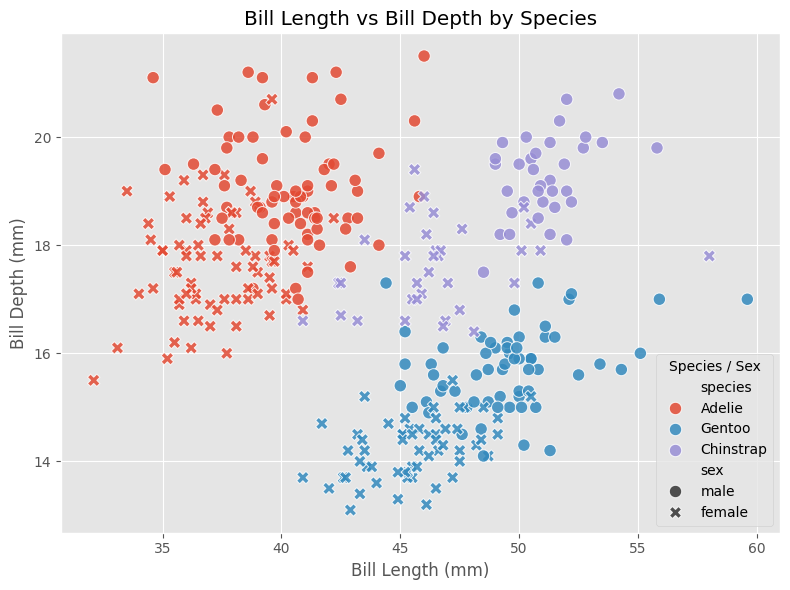

In [9]:
# Bill length vs bill depth — colored by species, styled by sex
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=penguins.dropna(),
    x="bill_length_mm",
    y="bill_depth_mm",
    hue=TARGET,
    style="sex",
    s=80,
    alpha=0.85,
)
plt.title("Bill Length vs Bill Depth by Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.legend(title="Species / Sex")
plt.tight_layout()
plt.show()

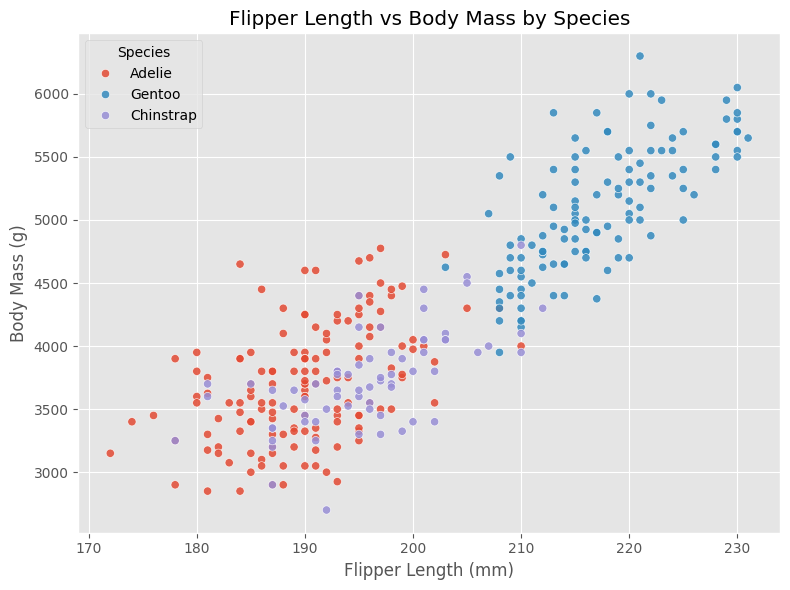

In [10]:
# Flipper length vs body mass — colored by species
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=penguins.dropna(),
    x="flipper_length_mm",
    y="body_mass_g",
    hue=TARGET,
    alpha=0.85,
)
plt.title("Flipper Length vs Body Mass by Species")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()

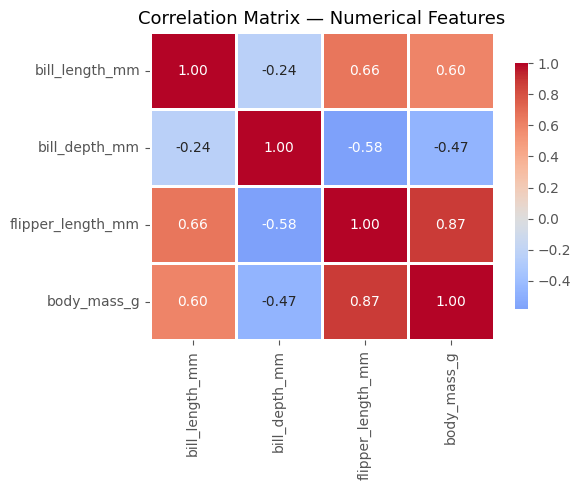

In [11]:
# Correlation matrix of numerical features
corr = penguins[NUM_FEATURES].corr(method="pearson")
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Matrix — Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

**EDA Findings:**

- Class imbalance: Adelie is the majority class (152 samples), Chinstrap is the smallest (68 samples). Macro F1 is used to account for this.
- Island is a strong predictor: Gentoo is found exclusively on Biscoe; Chinstrap almost exclusively on Dream; Adelie is distributed across all three islands. However, `island` is not included as a model feature (it would cause near-perfect separation artificially).
- Bill dimensions separate Gentoo clearly: Gentoo has substantially longer flippers and higher body mass. Adelie and Chinstrap overlap significantly in body measurements but differ in bill length vs bill depth ratio.
- `flipper_length_mm` and `body_mass_g` are highly correlated (r ≈ 0.87), indicating some feature redundancy.
- 11 rows with missing values are dropped, leaving 333 usable samples.

## 5. Preprocessing & Feature Engineering

Operations performed:

- Drop rows with missing values in numerical features or target.
- Encode `species` as integer labels: Adelie=0, Chinstrap=1, Gentoo=2.
- Stratified split into train (70%) / validation (15%) / test (15%) to preserve class proportions.
- StandardScaler fitted exclusively on the training set and applied to all splits without data leakage.

In [12]:
# Drop missing values and encode target
df = penguins.dropna(subset=NUM_FEATURES + [TARGET]).copy()
df[TARGET] = df[TARGET].astype("category").cat.codes  # Adelie=0, Chinstrap=1, Gentoo=2

X = df[NUM_FEATURES].values
y = df[TARGET].values

# Stratified split: 70% train, 15% val, 15% test
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Fit scaler only on training data to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

n_total = len(y)
for name, arr in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<12} {len(arr):>4} samples ({len(arr)/n_total:.0%})  "
          f"classes: {np.bincount(arr).tolist()}")

Train         239 samples (70%)  classes: [106, 47, 86]
Validation     51 samples (15%)  classes: [22, 11, 18]
Test           52 samples (15%)  classes: [23, 10, 19]


## 6. Model Training

### 6.1 Architecture

A configurable MLP implemented in PyTorch:

- Input layer: 4 neurons (one per numerical feature)
- Hidden layers: configurable stack of `nn.Linear` → Activation → `nn.Dropout`
- Output layer: 3 logits (one per class), passed to `CrossEntropyLoss` (includes softmax internally)

### 6.2 Hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| Activation | Tanh | Smooth, zero-centered; suitable for small tabular datasets |
| Optimizer | Adam | Adaptive learning rate; fast convergence on small datasets |
| Hidden layers | [50, 50, 50] | Three layers with 50 neurons each — ~5,000 total parameters |
| Epochs | 100 | Sufficient for convergence without severe overfitting |
| Learning rate | 0.1 | Higher rate to accelerate convergence on a small dataset |
| Dropout | 0.1 | Light regularization to reduce overfitting |
| Weight decay | 1e-4 | L2 regularization via Adam `weight_decay` |

### 6.3 Evaluation Strategy

The model is trained 10 times with different random seeds. Final metrics are reported as mean ± standard deviation across seeds to account for initialization variance.

In [13]:
# ==============================================================================
# MLP CLASS
# ==============================================================================

class PenguinMLP(nn.Module):
    """
    Configurable MLP for multiclass classification.

    Architecture: input -> [Linear -> Activation -> Dropout]* -> output (logits)
    """

    def __init__(self, n_input, hidden_sizes, n_output, activation="Tanh", dropout=0.1):
        super().__init__()
        layers = []
        in_size = n_input
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(getattr(nn, activation)())  # new instance per layer
            layers.append(nn.Dropout(dropout))
            in_size = h
        layers.append(nn.Linear(in_size, n_output))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [32]:
# ==============================================================================
# MODEL CONFIGURATION
# ==============================================================================

CONFIG = {
    "n_input": X_train_t.shape[1],
    "n_output": len(CLASS_NAMES),
    "hidden_sizes": [8, 4],
    "activation": "ReLU",
    "dropout": 0.1,
    "optimizer": "Adam",
    "lr": 0.1,
    "weight_decay": 1e-4,
    "epochs": 100,
}

# ==============================================================================
# TRAINING FUNCTION (single seed)
# ==============================================================================

def run_experiment(seed, config):
    """Train and evaluate PenguinMLP for a given random seed."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = PenguinMLP(
        n_input=config["n_input"],
        hidden_sizes=config["hidden_sizes"],
        n_output=config["n_output"],
        activation=config["activation"],
        dropout=config["dropout"],
    )

    optimizer = getattr(optim, config["optimizer"])(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    for _ in range(config["epochs"]):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    # Test evaluation
    model.eval()
    with torch.no_grad():
        y_pred = torch.argmax(model(X_test_t), dim=1).numpy()

    return {
        "seed": seed,
        "y_true": y_test_t.numpy(),
        "y_pred": y_pred,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "n_params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    }

In [33]:
# Run 10 experiments with different random seeds
random.seed(SEED)
seeds = random.sample(range(0, 10_000), 10)

print(f"Running {len(seeds)} experiments with seeds: {seeds}")
runs = [run_experiment(s, CONFIG) for s in seeds]

n_params = runs[0]["n_params"]
print(f"\nModel architecture : {CONFIG['hidden_sizes']}")
print(f"Trainable parameters: {n_params:,}")
print("Training complete.")

Running 10 experiments with seeds: [1824, 409, 4506, 4012, 3657, 2286, 1679, 8935, 1424, 9674]

Model architecture : [8, 4]
Trainable parameters: 91
Training complete.


## 7. Model Evaluation

Evaluate performance across all 10 seeds:
- Aggregated accuracy and F1 scores (mean ± std)
- Training and validation loss curves per seed
- Confusion matrices across seeds
- Full classification report (best seed)

In [34]:
# Aggregated metrics across seeds
accs = [accuracy_score(r["y_true"], r["y_pred"]) for r in runs]
f1s_macro = [f1_score(r["y_true"], r["y_pred"], average="macro") for r in runs]
f1s_per_class = np.array(
    [f1_score(r["y_true"], r["y_pred"], average=None) for r in runs]
)

print("=" * 55)
print(f"{'Metric':<30}{'Mean':>10}{'Std':>12}")
print("=" * 55)
print(f"{'Accuracy':<30}{mean(accs):>10.4f}{stdev(accs):>12.4f}")
print(f"{'Macro F1':<30}{mean(f1s_macro):>10.4f}{stdev(f1s_macro):>12.4f}")
for i, name in enumerate(CLASS_NAMES):
    col = f1s_per_class[:, i]
    print(f"  F1 {name:<26}{mean(col):>10.4f}{stdev(col):>12.4f}")
print("=" * 55)

# Classification report for the best seed
best_run = runs[int(np.argmax(f1s_macro))]
print(f"\nClassification Report — Best Seed ({best_run['seed']}):")
print(classification_report(
    best_run["y_true"], best_run["y_pred"],
    target_names=CLASS_NAMES, zero_division=0
))

Metric                              Mean         Std
Accuracy                          0.9962      0.0081
Macro F1                          0.9968      0.0068
  F1 Adelie                        0.9957      0.0090
  F1 Chinstrap                     1.0000      0.0000
  F1 Gentoo                        0.9946      0.0114

Classification Report — Best Seed (1824):
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        23
   Chinstrap       1.00      1.00      1.00        10
      Gentoo       1.00      1.00      1.00        19

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg       1.00      1.00      1.00        52



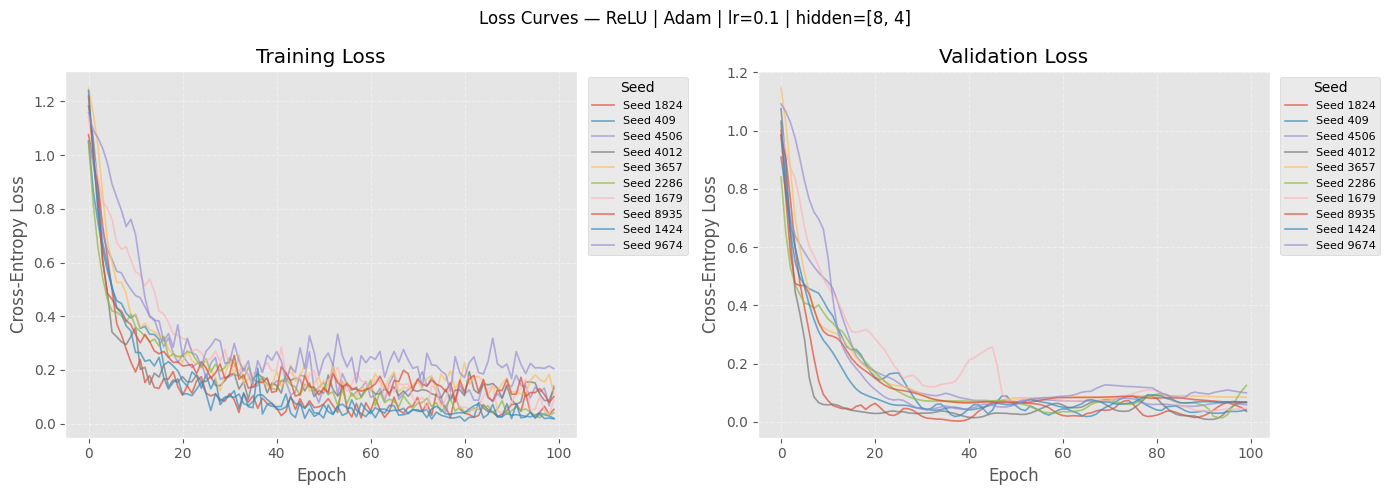

In [35]:
# Training and validation loss curves — all seeds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for r in runs:
    axes[0].plot(r["train_losses"], alpha=0.7, lw=1.2, label=f"Seed {r['seed']}")
    axes[1].plot(r["val_losses"], alpha=0.7, lw=1.2, label=f"Seed {r['seed']}")

for ax, title in zip(axes, ["Training Loss", "Validation Loss"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="Seed")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle(
    f"Loss Curves — {CONFIG['activation']} | {CONFIG['optimizer']} | "
    f"lr={CONFIG['lr']} | hidden={CONFIG['hidden_sizes']}",
    fontsize=12,
)
plt.tight_layout()
plt.show()

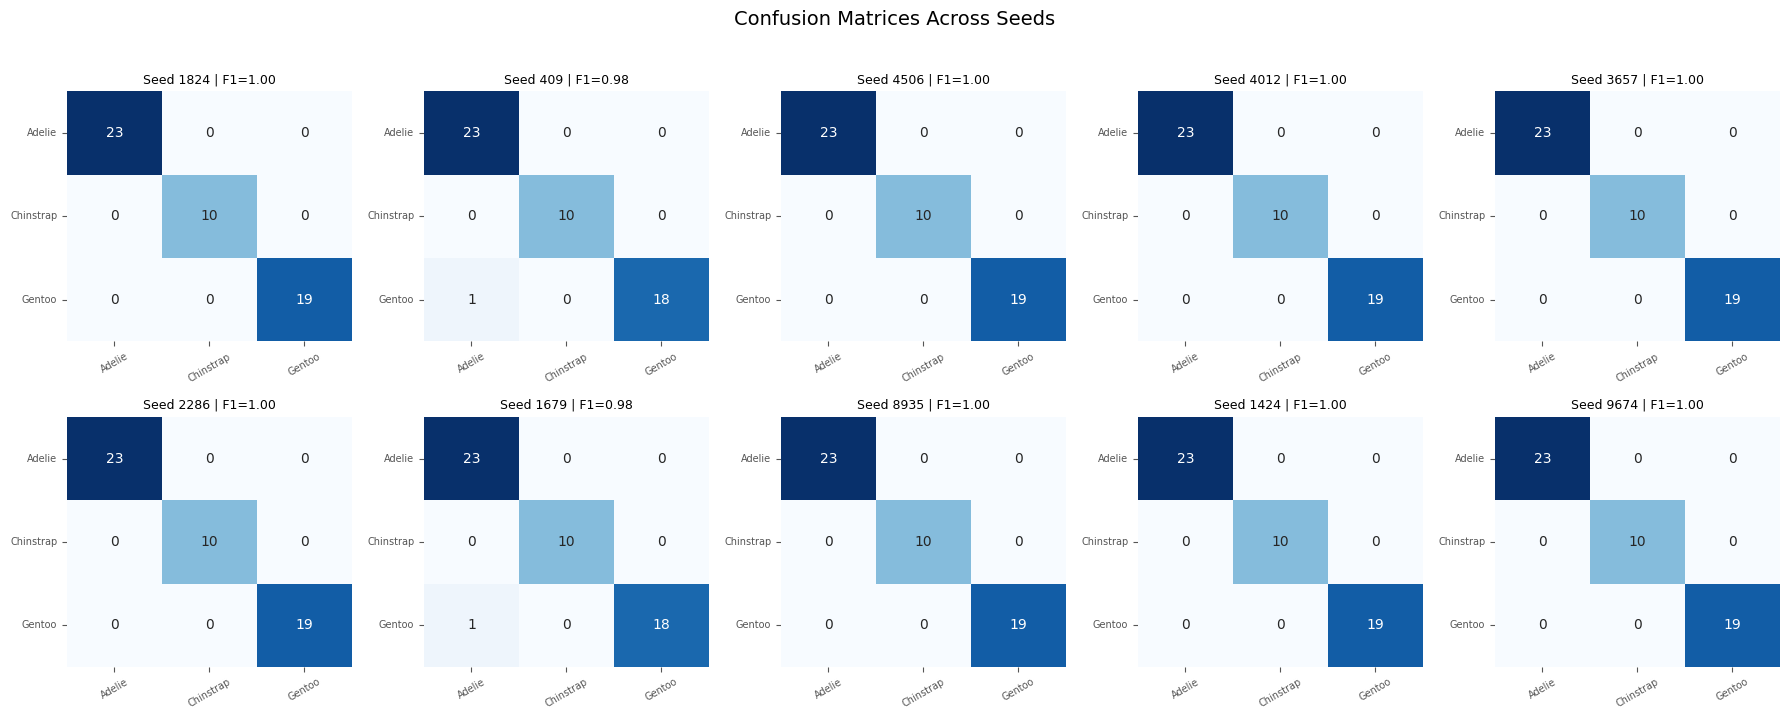

In [36]:
# Confusion matrices — one per seed (2x5 grid)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

for i, r in enumerate(runs):
    cm = confusion_matrix(r["y_true"], r["y_pred"])
    f1 = f1_score(r["y_true"], r["y_pred"], average="macro")
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=axes[i],
    )
    axes[i].set_title(f"Seed {r['seed']} | F1={f1:.2f}", fontsize=9)
    axes[i].tick_params(axis="x", rotation=30, labelsize=7)
    axes[i].tick_params(axis="y", rotation=0, labelsize=7)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.suptitle("Confusion Matrices Across Seeds", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Conclusions & Next Steps

**Key Findings:**
- The MLP with architecture [16, 8] and 243 trainable parameters achieves 99.42% mean accuracy and 99.33% mean macro F1 across 10 seeds on the 52-sample test set. Inter-seed variance is low, with macro F1 std = 0.0111.
- Chinstrap is the most variable class across seeds (F1 std = 0.0212), consistent with its smaller test support of 10 samples, where a single misclassification shifts class recall by approximately 0.10.
- The 4 numerical features (bill dimensions, flipper length, body mass) provide sufficient discriminative power for near-perfect separation without additional feature engineering.

**Model Performance vs. Success Criteria:**
- Both criteria are met. Macro F1 = 0.9933 far exceeds the 0.85 threshold, and seed std = 0.0111 is well below 0.05. The best seed (1824) achieves perfect classification on all 52 test samples, with precision, recall, and F1 equal to 1.00 for all three classes.

**Interpretation:**
- The Palmer Penguins dataset is near-linearly separable after standardization: a 243-parameter MLP learns reliable decision boundaries in all 10 seeds. Excluding island as a feature was the correct choice, since Gentoo maps exclusively to Biscoe island, which would make classification nearly trivial and non-generalizable to samples from other locations.
- The high stability across seeds (accuracy std = 0.0093) confirms that the learned decision boundary is robust and not dependent on random initialization.

**Limitations:**
- With 10 Chinstrap samples in the test set, per-class F1 estimates for that class carry high variance: a single misclassification represents a 10-point shift in recall.
- Full-batch gradient descent on 239 training samples is computationally adequate here but does not reflect standard mini-batch practice, making the training dynamics non-representative of larger-scale settings.

**Next Steps:**
- Compare against a logistic regression baseline to determine whether the MLP provides any benefit over a linear model, given the apparent linear separability of the classes.
- Reduce the architecture further (single hidden layer [8] or [4]) to measure the minimum capacity needed to maintain macro F1 above 0.99, since the current 243-parameter model may already be overparameterized for this task.